## SETUP

In [1]:
from pathlib import Path

import pandas as pd
import tensorflow as tf
import yaml

from breast_cancer.data import optimize_dataset, prepare_dataset
from breast_cancer.models import build_ensemble_shared_backbone
from breast_cancer.utils import get_save_path
from breast_cancer.utils.plots import plot_history

2025-09-21 14:39:12.521176: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-21 14:39:12.598999: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-21 14:39:12.615560: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-21 14:39:12.961915: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvi

In [2]:
# Check installed tensorflow version
print(f"Tensorflow version: {tf.__version__}")

# Check GPU availability
print(f"GPU List: {tf.config.list_physical_devices('GPU')}")

Tensorflow version: 2.10.1
GPU List: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Import general configurations
with open("../configs/default.yml") as f:
    default_cfg = yaml.load(f, Loader=yaml.FullLoader)

# Import training configurations
with open("../configs/training.yml") as f:
    training_cfg = yaml.load(f, Loader=yaml.FullLoader)

# Import model configurations
with open("../configs/model_ensemble_shared.yml") as f:
    model_cfg = yaml.load(f, Loader=yaml.FullLoader)

In [40]:
dir_data_split = Path(default_cfg["dirs"]["data_split"])
dir_data_split.mkdir(parents=True, exist_ok=True)

dir_model_logs = Path(default_cfg["dirs"]["model_logs"])
dir_model_logs.mkdir(parents=True, exist_ok=True)

dir_model_initial = Path(default_cfg["dirs"]["model_initial"])
dir_model_initial.mkdir(parents=True, exist_ok=True)

dir_model_final = Path(default_cfg["dirs"]["model_final"])
dir_model_final.mkdir(parents=True, exist_ok=True)

In [5]:
def get_dataset(image_paths, image_labels, image_resize, dataset_cfg):
    if isinstance(image_resize, int):
        image_resize = (image_resize, image_resize)
    dataset = prepare_dataset(image_paths, image_labels, image_resize)
    dataset = optimize_dataset(dataset, **dataset_cfg)
    return dataset

In [6]:
# Set random seeds
tf.random.set_seed(default_cfg["random_seed"])

In [7]:
EPOCHS = 80

## MODEL STARTING POINT

In [8]:
from tensorflow.keras.applications import InceptionV3

# Build backbone from pretrained model
new_cfg = model_cfg["base_model_args"].copy()
backbone = InceptionV3(**model_cfg["base_model_args"])

# Build model from spec
model_cfg["model_args"]["name"] = f"ensemble_{backbone.name}"
model = build_ensemble_shared_backbone(backbone, model_cfg["model_args"])
model.summary()

# Save initial weights for multiple training configurations
save_path = get_save_path(default_cfg["dirs"]["model_initial"], f"{model.name}_{backbone.name}", "")
model.save_weights(save_path)
print(f"Model initial weights are saved at {save_path}")

2025-09-21 14:39:13.939788: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-21 14:39:14.043420: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22177 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:02:00.0, compute capability: 8.9


Model: "ensemble_inception_v3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 inception_v3 (Functional)      (None, 6, 6, 2048)   21802784    ['input_2[0][0]']                
                                                                                                  
 transition_layer (GlobalAverag  (None, 2048)        0           ['inception_v3[0][0]']           
 ePooling2D)                                                                                      
                                                                              

## MODEL EXPLORATION

#### Split by image ID

In [9]:
df_train_image_random = pd.read_csv(dir_data_split / "train_image_random_aug.csv") # get the augmented version
df_val_image_random = pd.read_csv(dir_data_split / "val_image_random.csv")

df_train_image_random.head(3)

,Unnamed: 0,raw,processed,imageID,patientID,label,augmented,augmentID
0,0,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-9
1,1,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-8
2,2,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-7


In [10]:
from tensorflow.image import grayscale_to_rgb

ds_train_image_random = get_dataset(
    df_train_image_random["augmented"].values,
    df_train_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_val_image_random = get_dataset(
    df_val_image_random["processed"].values,
    df_val_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["test"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [11]:
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC, BinaryAccuracy, Precision, Recall
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)

# Load the model and freeze backbone
model.load_weights(save_path)
backbone = model.get_layer("inception_v3")
backbone.trainable = False

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["initial_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="val_loss", **training_cfg["initial_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="val_loss", **training_cfg["initial_training"]["reduce_on_plateau"])

In [12]:
# Train head only
history_image1 = model.fit(
    ds_train_image_random,
    validation_data=ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


2025-09-21 14:39:22.647834: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8905
2025-09-21 14:39:22.661724: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 14:39:22.662496: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 14:39:22.662507: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2025-09-21 14:39:22.664087: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 14:39:22.664162: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2025-09-21 14:39:22.737280: I tensorflow/stream_executor/cuda/c

323/323 [==============================] - 17s 33ms/step - loss: 0.7660 - auc: 0.5833 - binary_accuracy: 0.5727 - precision: 0.4833 - recall: 0.5199 - val_loss: 0.7030 - val_auc: 0.7087 - val_binary_accuracy: 0.6475 - val_precision: 0.5659 - val_recall: 0.6186 - lr: 1.0000e-04
Epoch 2/80
323/323 [==============================] - 10s 30ms/step - loss: 0.7563 - auc: 0.5976 - binary_accuracy: 0.5865 - precision: 0.4988 - recall: 0.4888 - val_loss: 0.7129 - val_auc: 0.7026 - val_binary_accuracy: 0.6475 - val_precision: 0.5570 - val_recall: 0.7034 - lr: 1.0000e-04
Epoch 3/80
323/323 [==============================] - 10s 30ms/step - loss: 0.7394 - auc: 0.6260 - binary_accuracy: 0.6113 - precision: 0.5323 - recall: 0.4760 - val_loss: 0.7426 - val_auc: 0.7181 - val_binary_accuracy: 0.5881 - val_precision: 0.5000 - val_recall: 0.9025 - lr: 1.0000e-04
Epoch 4/80
321/323 [============================>.] - ETA: 0s - loss: 0.7319 - auc: 0.6321 - binary_accuracy: 0.6213 - precision: 0.5472 - recal

In [13]:
# Unfreeze parts of the backbone for fine tuning
backbone_layers = backbone.layers
start_trainable = -int(0.2*len(backbone_layers))

for l in backbone_layers[start_trainable:]:
    l.trainable = True

# Set new learning rate
tf.keras.backend.set_value(model.optimizer.lr, 1e-5)

# Fine tune head and last 20% backbone layers
history_image2 = model.fit(
    ds_train_image_random,
    validation_data = ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
  1/323 [..............................] - ETA: 49s - loss: 0.5007 - auc: 0.0000e+00 - binary_accuracy: 0.8906 - precision: 0.0000e+00 - recall: 0.0000e+00

323/323 [==============================] - 10s 30ms/step - loss: 0.5810 - auc: 0.8232 - binary_accuracy: 0.7560 - precision: 0.7649 - recall: 0.5897 - val_loss: 0.6231 - val_auc: 0.7708 - val_binary_accuracy: 0.7208 - val_precision: 0.6545 - val_recall: 0.6822 - lr: 1.0000e-05
Epoch 2/80
323/323 [==============================] - 10s 30ms/step - loss: 0.5831 - auc: 0.8205 - binary_accuracy: 0.7520 - precision: 0.7544 - recall: 0.5913 - val_loss: 0.6242 - val_auc: 0.7732 - val_binary_accuracy: 0.7138 - val_precision: 0.6374 - val_recall: 0.7076 - lr: 1.0000e-05
Epoch 3/80
323/323 [==============================] - 10s 30ms/step - loss: 0.5847 - auc: 0.8178 - binary_accuracy: 0.7526 - precision: 0.7559 - recall: 0.5911 - val_loss: 0.6232 - val_auc: 0.7719 - val_binary_accuracy: 0.7225 - val_precision: 0.6534 - val_recall: 0.6949 - lr: 1.0000e-05
Epoch 4/80
321/323 [============================>.] - ETA: 0s - loss: 0.5828 - auc: 0.8203 - binary_accuracy: 0.7526 - precision: 0.7542 - recal

In [14]:
# Unfreeze all layers for fine tuning
model.trainable = True

# Fine tune the model
history_image3 = model.fit(
    ds_train_image_random,
    validation_data = ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
  2/323 [..............................] - ETA: 22s - loss: 0.4591 - auc: 0.0000e+00 - binary_accuracy: 0.9453 - precision: 0.0000e+00 - recall: 0.0000e+00

323/323 [==============================] - 10s 30ms/step - loss: 0.5611 - auc: 0.8482 - binary_accuracy: 0.7754 - precision: 0.7827 - recall: 0.6307 - val_loss: 0.6137 - val_auc: 0.7777 - val_binary_accuracy: 0.7260 - val_precision: 0.6890 - val_recall: 0.6102 - lr: 1.8014e-07
Epoch 2/80
323/323 [==============================] - 10s 30ms/step - loss: 0.5641 - auc: 0.8426 - binary_accuracy: 0.7716 - precision: 0.7762 - recall: 0.6269 - val_loss: 0.6143 - val_auc: 0.7777 - val_binary_accuracy: 0.7260 - val_precision: 0.6854 - val_recall: 0.6186 - lr: 1.8014e-07
Epoch 3/80
323/323 [==============================] - 10s 30ms/step - loss: 0.5642 - auc: 0.8442 - binary_accuracy: 0.7747 - precision: 0.7795 - recall: 0.6327 - val_loss: 0.6141 - val_auc: 0.7781 - val_binary_accuracy: 0.7260 - val_precision: 0.6854 - val_recall: 0.6186 - lr: 1.8014e-07
Epoch 4/80
321/323 [============================>.] - ETA: 0s - loss: 0.5622 - auc: 0.8453 - binary_accuracy: 0.7725 - precision: 0.7726 - recal

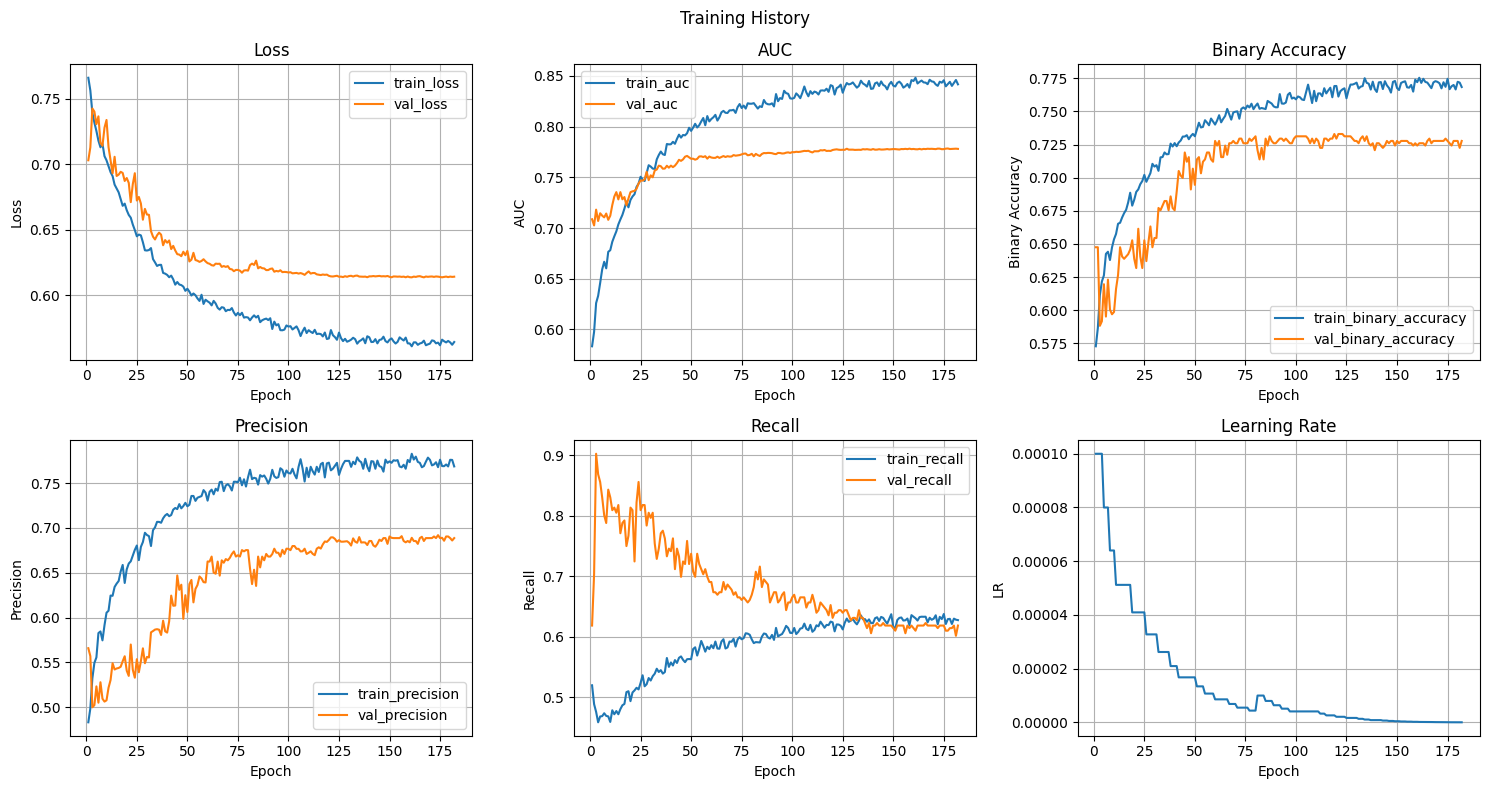

In [15]:
def append_histories(*histories):
    import re
    merged = {}
    for h in histories:
        for k, v in h.history.items():
            new_k = re.sub(r'_\d+$', '', k)
            merged.setdefault(new_k, []).extend(v)
    return merged

all_histories = append_histories(history_image1, history_image2, history_image3)

plot_history(all_histories)

In [16]:
logger_path = str(dir_model_logs/model.name/f"initial_{model.name}_{backbone.name}_image_random.csv")
Path(logger_path).parent.mkdir(exist_ok=True)

pd.DataFrame(all_histories).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/ensemble_inception_v3/initial_ensemble_inception_v3_inception_v3_image_random.csv'

#### Split by Patient ID

In [17]:
df_train_patient_random = pd.read_csv(dir_data_split / "train_patient_random_aug.csv") # get the augmented version
df_val_patient_random = pd.read_csv(dir_data_split / "val_patient_random.csv")

df_train_patient_random.head(3)

,Unnamed: 0,raw,processed,imageID,patientID,label,augmented,augmentID
0,0,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-9
1,1,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-8
2,2,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-7


In [18]:
ds_train_patient_random = get_dataset(
    df_train_patient_random["augmented"].values,
    df_train_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_val_patient_random = get_dataset(
    df_val_patient_random["processed"].values,
    df_val_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["test"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [19]:
# Load the model and freeze backbone
model.load_weights(save_path)
backbone = model.get_layer("inception_v3")
backbone.trainable = False

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["initial_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="val_loss", **training_cfg["initial_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="val_loss", **training_cfg["initial_training"]["reduce_on_plateau"])

In [20]:
# Train head only
history_patient1 = model.fit(
    ds_train_patient_random,
    validation_data=ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


316/316 [==============================] - 15s 33ms/step - loss: 0.7682 - auc_1: 0.5768 - binary_accuracy: 0.5684 - precision_1: 0.4695 - recall_1: 0.5192 - val_loss: 0.7174 - val_auc_1: 0.6679 - val_binary_accuracy: 0.6250 - val_precision_1: 0.5223 - val_recall_1: 0.6085 - lr: 1.0000e-04
Epoch 2/80
316/316 [==============================] - 10s 30ms/step - loss: 0.7565 - auc_1: 0.5941 - binary_accuracy: 0.5879 - precision_1: 0.4903 - recall_1: 0.4876 - val_loss: 0.7335 - val_auc_1: 0.6834 - val_binary_accuracy: 0.5765 - val_precision_1: 0.4781 - val_recall_1: 0.7736 - lr: 1.0000e-04
Epoch 3/80
316/316 [==============================] - 10s 30ms/step - loss: 0.7410 - auc_1: 0.6170 - binary_accuracy: 0.6048 - precision_1: 0.5128 - recall_1: 0.4525 - val_loss: 0.7341 - val_auc_1: 0.6720 - val_binary_accuracy: 0.5765 - val_precision_1: 0.4777 - val_recall_1: 0.7594 - lr: 1.0000e-04
Epoch 4/80
315/316 [============================>.] - ETA: 0s - loss: 0.7320 - auc_1: 0.6317 - binary_accura

In [21]:
# Unfreeze parts of the backbone for fine tuning
backbone_layers = backbone.layers
start_trainable = -int(0.2*len(backbone_layers))

for l in backbone_layers[start_trainable:]:
    l.trainable = True

# Set new learning rate
tf.keras.backend.set_value(model.optimizer.lr, 1e-5)

# Fine tune head and last 20% backbone layers
history_patient2 = model.fit(
    ds_train_patient_random,
    validation_data = ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
 16/316 [>.............................] - ETA: 9s - loss: 0.5065 - auc_1: 0.0000e+00 - binary_accuracy: 0.8877 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 

316/316 [==============================] - 10s 30ms/step - loss: 0.5868 - auc_1: 0.8124 - binary_accuracy: 0.7462 - precision_1: 0.7549 - recall_1: 0.5513 - val_loss: 0.6586 - val_auc_1: 0.7069 - val_binary_accuracy: 0.6586 - val_precision_1: 0.5736 - val_recall_1: 0.5330 - lr: 1.0000e-05
Epoch 2/80
316/316 [==============================] - 9s 30ms/step - loss: 0.5879 - auc_1: 0.8110 - binary_accuracy: 0.7454 - precision_1: 0.7538 - recall_1: 0.5499 - val_loss: 0.6591 - val_auc_1: 0.7060 - val_binary_accuracy: 0.6642 - val_precision_1: 0.5792 - val_recall_1: 0.5519 - lr: 1.0000e-05
Epoch 3/80
316/316 [==============================] - 10s 30ms/step - loss: 0.5850 - auc_1: 0.8151 - binary_accuracy: 0.7504 - precision_1: 0.7576 - recall_1: 0.5625 - val_loss: 0.6587 - val_auc_1: 0.7065 - val_binary_accuracy: 0.6549 - val_precision_1: 0.5652 - val_recall_1: 0.5519 - lr: 1.0000e-05
Epoch 4/80
316/316 [==============================] - 10s 30ms/step - loss: 0.5860 - auc_1: 0.8143 - binary_a

In [22]:
# Unfreeze all layers for fine tuning
model.trainable = True

# Fine tune the model
history_patient3 = model.fit(
    ds_train_patient_random,
    validation_data = ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
  3/316 [..............................] - ETA: 13s - loss: 0.4577 - auc_1: 0.0000e+00 - binary_accuracy: 0.9375 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00

316/316 [==============================] - 10s 30ms/step - loss: 0.5700 - auc_1: 0.8336 - binary_accuracy: 0.7652 - precision_1: 0.7742 - recall_1: 0.5917 - val_loss: 0.6565 - val_auc_1: 0.7091 - val_binary_accuracy: 0.6679 - val_precision_1: 0.6012 - val_recall_1: 0.4764 - lr: 1.3422e-06
Epoch 2/80
316/316 [==============================] - 10s 30ms/step - loss: 0.5688 - auc_1: 0.8353 - binary_accuracy: 0.7632 - precision_1: 0.7695 - recall_1: 0.5915 - val_loss: 0.6561 - val_auc_1: 0.7095 - val_binary_accuracy: 0.6679 - val_precision_1: 0.6037 - val_recall_1: 0.4670 - lr: 1.3422e-06
Epoch 3/80
316/316 [==============================] - 10s 30ms/step - loss: 0.5671 - auc_1: 0.8376 - binary_accuracy: 0.7671 - precision_1: 0.7762 - recall_1: 0.5958 - val_loss: 0.6563 - val_auc_1: 0.7096 - val_binary_accuracy: 0.6679 - val_precision_1: 0.6062 - val_recall_1: 0.4575 - lr: 1.3422e-06
Epoch 4/80
316/316 [==============================] - 10s 30ms/step - loss: 0.5696 - auc_1: 0.8338 - binary_

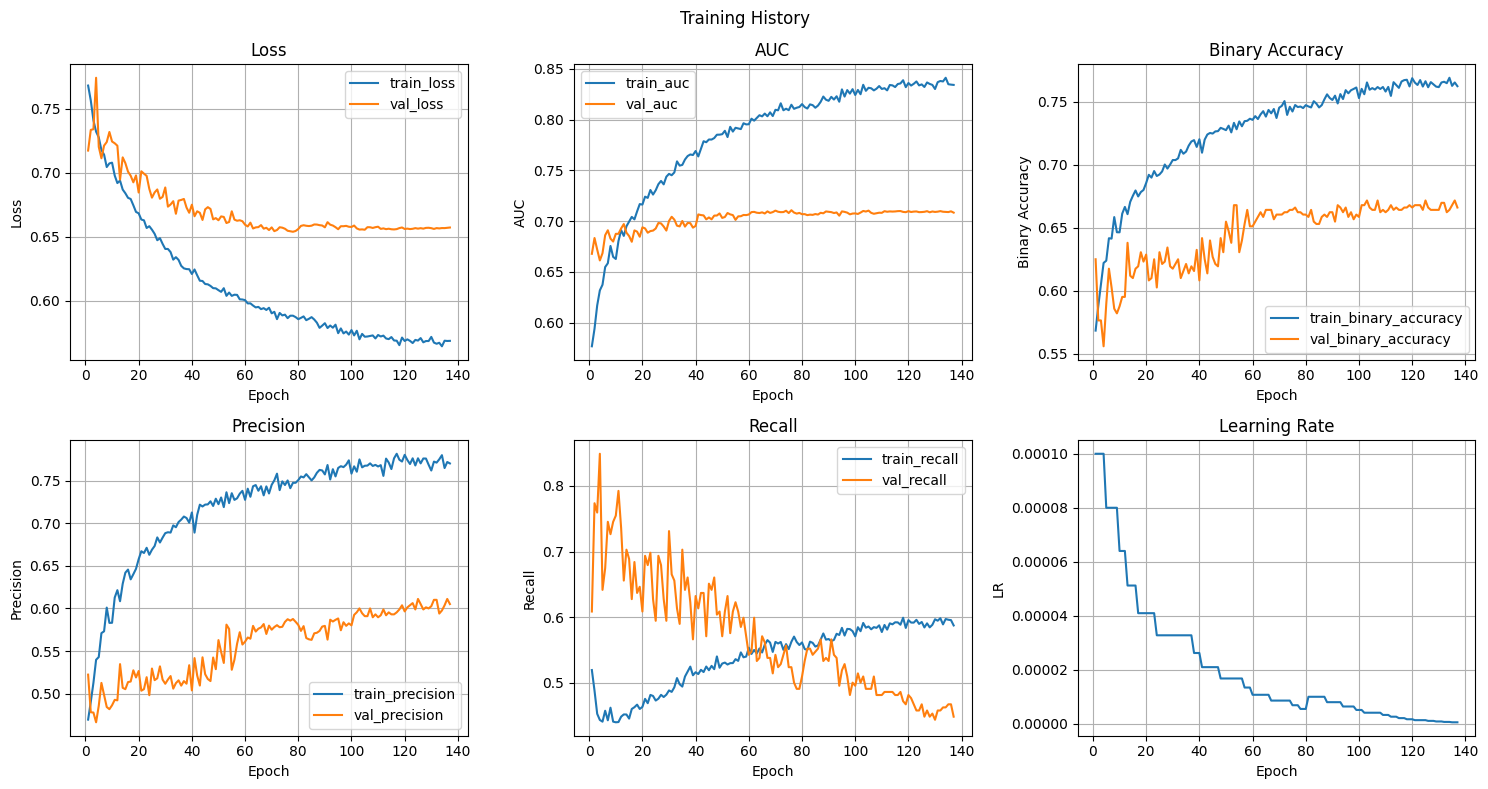

In [23]:
all_histories = append_histories(history_patient1, history_patient2, history_patient3)

plot_history(all_histories)

In [24]:
logger_path = str(dir_model_logs/model.name/f"initial_{model.name}_{backbone.name}_patient_random.csv")

pd.DataFrame(all_histories).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/ensemble_inception_v3/initial_ensemble_inception_v3_inception_v3_patient_random.csv'

## FINAL EVALUATION

#### Split by Image ID

In [35]:
df_train_image_random = pd.read_csv(dir_data_split / "train_image_random_aug.csv") # get the augmented version
df_val_image_random = pd.read_csv(dir_data_split / "val_image_random_aug.csv") # get the augmented version

# Combine train and val data for full training
df_full_train_image_random = pd.concat([df_train_image_random, df_val_image_random], ignore_index=True)

ds_full_train_image_random = get_dataset(
    df_full_train_image_random["augmented"].values,
    df_full_train_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [36]:
# Load the model initial weights
model.load_weights(save_path)

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["final_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="loss", **training_cfg["final_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="loss", **training_cfg["final_training"]["reduce_on_plateau"])

In [37]:
# Train model
history_image_full = model.fit(
    ds_full_train_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=80, # when model start to overfit during experiments
)

Epoch 1/80


403/403 [==============================] - 42s 92ms/step - loss: 0.7081 - auc_4: 0.7017 - binary_accuracy: 0.6503 - precision_4: 0.5673 - recall_4: 0.6399 - lr: 1.0000e-04
Epoch 2/80
403/403 [==============================] - 37s 92ms/step - loss: 0.6413 - auc_4: 0.7909 - binary_accuracy: 0.7303 - precision_4: 0.6559 - recall_4: 0.7275 - lr: 1.0000e-04
Epoch 3/80
403/403 [==============================] - 37s 92ms/step - loss: 0.5935 - auc_4: 0.8316 - binary_accuracy: 0.7683 - precision_4: 0.7020 - recall_4: 0.7613 - lr: 1.0000e-04
Epoch 4/80
403/403 [==============================] - 37s 92ms/step - loss: 0.5423 - auc_4: 0.8716 - binary_accuracy: 0.8082 - precision_4: 0.7434 - recall_4: 0.8168 - lr: 1.0000e-04
Epoch 5/80
403/403 [==============================] - 37s 92ms/step - loss: 0.5040 - auc_4: 0.8947 - binary_accuracy: 0.8241 - precision_4: 0.7595 - recall_4: 0.8390 - lr: 1.0000e-04
Epoch 6/80
403/403 [==============================] - 37s 93ms/step - loss: 0.5030 - auc_4: 0.89

In [41]:
# Save final model
model.save(dir_model_final/model.name/f"{model.name}_{backbone.name}_image_random.h5")

In [42]:
#Export final training history
logger_path = str(dir_model_logs/model.name/f"full_{model.name}_{backbone.name}_image_random.csv")

pd.DataFrame(history_image_full.history).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/ensemble_inception_v3/full_ensemble_inception_v3_inception_v3_image_random.csv'

In [ ]:
# Setup testing data for evaluation
df_test_image_random = pd.read_csv(dir_data_split / "test_image_random.csv")

ds_test_image_random = prepare_dataset( # use prepare dataset, only converting path to image and get labels
    df_test_image_random["processed"].values,
    df_test_image_random["label"].values,
    image_resize=(default_cfg["image_resize"], default_cfg["image_resize"])
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_test_image_random = ds_test_image_random.batch(64)

In [39]:
# Final evaluation
model.evaluate(ds_test_image_random)

 1/11 [=>............................] - ETA: 6s - loss: 0.8543 - auc_4: 0.0000e+00 - binary_accuracy: 0.7656 - precision_4: 0.0000e+00 - recall_4: 0.0000e+00

11/11 [==============================] - 1s 27ms/step - loss: 1.1877 - auc_4: 0.7689 - binary_accuracy: 0.6804 - precision_4: 0.5656 - recall_4: 0.7971   


[1.1876988410949707,
 0.7689201235771179,
 0.6803977489471436,
 0.5655527114868164,
 0.7971014380455017]

#### Split by Patient ID

In [43]:
df_train_patient_random = pd.read_csv(dir_data_split / "train_patient_random_aug.csv") # get the augmented version
df_val_patient_random = pd.read_csv(dir_data_split / "val_patient_random_aug.csv") # get the augmented version

# Combine train and val data for full training
df_full_train_patient_random = pd.concat([df_train_patient_random, df_val_patient_random], ignore_index=True)

ds_full_train_patient_random = get_dataset(
    df_full_train_patient_random["augmented"].values,
    df_full_train_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [44]:
# Load the model initial weights
model.load_weights(save_path)

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["final_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="loss", **training_cfg["final_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="loss", **training_cfg["final_training"]["reduce_on_plateau"])

In [45]:
# Train model
history_patient_full = model.fit(
    ds_full_train_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=40, # when model start to overfit during experiments
)

Epoch 1/40
392/392 [==============================] - 42s 93ms/step - loss: 0.6974 - auc_5: 0.7169 - binary_accuracy: 0.6648 - precision_5: 0.5750 - recall_5: 0.6417 - lr: 1.0000e-04
Epoch 2/40
392/392 [==============================] - 36s 92ms/step - loss: 0.6494 - auc_5: 0.7737 - binary_accuracy: 0.7232 - precision_5: 0.6405 - recall_5: 0.7119 - lr: 1.0000e-04
Epoch 3/40
392/392 [==============================] - 36s 92ms/step - loss: 0.6047 - auc_5: 0.8176 - binary_accuracy: 0.7589 - precision_5: 0.6810 - recall_5: 0.7549 - lr: 1.0000e-04
Epoch 4/40
392/392 [==============================] - 36s 93ms/step - loss: 0.5718 - auc_5: 0.8526 - binary_accuracy: 0.7874 - precision_5: 0.7059 - recall_5: 0.8090 - lr: 1.0000e-04
Epoch 5/40
392/392 [==============================] - 36s 92ms/step - loss: 0.5453 - auc_5: 0.8573 - binary_accuracy: 0.7948 - precision_5: 0.7247 - recall_5: 0.7905 - lr: 1.0000e-04
Epoch 6/40
392/392 [==============================] - 36s 92ms/step - loss: 0.4956 - 

In [46]:
# Save final model
model.save(dir_model_final/model.name/f"{model.name}_{backbone.name}_patient_random.h5")

In [47]:
#Export final training history
logger_path = str(dir_model_logs/model.name/f"full_{model.name}_{backbone.name}_patient_random.csv")

pd.DataFrame(history_patient_full.history).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/ensemble_inception_v3/full_ensemble_inception_v3_inception_v3_patient_random.csv'

In [48]:
# Setup testing data for evaluation
df_test_patient_random = pd.read_csv(dir_data_split / "test_patient_random.csv")

ds_test_patient_random = prepare_dataset( # use prepare dataset, only converting path to image and get labels
    df_test_patient_random["processed"].values,
    df_test_patient_random["label"].values,
    image_resize=(default_cfg["image_resize"], default_cfg["image_resize"])
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_test_patient_random = ds_test_patient_random.batch(64)

In [49]:
# Final evaluation
model.evaluate(ds_test_patient_random)

13/13 [==============================] - 3s 111ms/step - loss: 0.7583 - auc_5: 0.7908 - binary_accuracy: 0.6997 - precision_5: 0.6130 - recall_5: 0.8131


[0.7583393454551697,
 0.7907582521438599,
 0.6997455358505249,
 0.6129754185676575,
 0.8130564093589783]